In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import qutip as qt
import os 
H = np.array([[1],[0]])
V = np.array([[0],[1]])
D = 1/np.sqrt(2)*(H+V)
A = 1/np.sqrt(2)*(H-V)
R = 1/np.sqrt(2)*(H+1j*V)
L = 1/np.sqrt(2)*(H-1j*V)
basismap = {
    'H': H,
    'V': V,
    'D': D,
    'A': A,
    'R': R,
    'L': L
}

I = np.array([[1,0],[0,1]])
X = np.array([[0,1],[1,0]])
Y = np.array([[0,-1j],[1j,0]])
Z = np.array([[1,0],[0,-1]])
pauli = [I,X,Y,Z]

# Q1, linear inversion method to find density operator

We're given measurments for 4 different states (H,V,D,R), so it seems sensible to use linear inversion in this case. To calculate this, we use born's rule to construct a system of linear equations, then we invert this system of queation to construct our density matrix. We know the total power should be 4mW by adding the power from the HV measurements, so given our measurements it's sensible to assume our state/density matrix would be the one corresponding to a D state. If we had instead measured the A and L states, we would have measure A=0mW and L=2mW respectively with H and V staying the same. 

In [2]:
def linear_inversion_tomo(measurements, basis, basislabel):
    measurements = np.array(measurements)
    #calculate projectors over basis states
    projectors = [s@s.conj().T for s in basis]
    #construct system of equations (i.e. each equation solves for one parameter of our density matrix)
    S = np.array([M.flatten() for M in projectors])
    #invertS to find elements of rho, reshape to be the right dimension, normalize
    rho_vec = np.linalg.inv(S) @ measurements
    rho = rho_vec.reshape((2,2))
    rho_norm = rho/np.trace(rho)
    with np.printoptions(3, suppress = True):
        print(f'Measurements {measurements} in the {basislabel} basis: ')
        print(f"Total input power: {np.trace(rho)}")
        print(f'Reconstructed state density matrix: \n {rho_norm} \n')
        
        
    #return rho_norm

linear_inversion_tomo([2,2,4,2], [H,V,D,R], "HVDR")
linear_inversion_tomo([2,2,0,2], [H,V,A,L], "HVDR")


Measurements [2 2 4 2] in the HVDR basis: 
Total input power: (4+0j)
Reconstructed state density matrix: 
 [[0.5+0.j 0.5+0.j]
 [0.5-0.j 0.5+0.j]] 

Measurements [2 2 0 2] in the HVDR basis: 
Total input power: (4+0j)
Reconstructed state density matrix: 
 [[0.5+0.j 0.5-0.j]
 [0.5+0.j 0.5+0.j]] 



# Q2
Now we write a MLE program for calculating the density matrix. Following the notes, we use a cholesky decomposition to parametrize our matrix. We assume poissonian uncertainty and we minimize the function found in the notes to find our parameters. We also create a 2nd loss function that is adapted specifically to power measurements. We test the program with the same counts as in Q1 so we should get the same density matrix (and we do). We also let our algorithm find the additional parameter (i.e. total count N or total input power) as an additional parameter we optimize for. 

In [16]:
def read_measurements(filename):
    '''
    Helper function to load a file of measurment with corresponding basis, will generate a list with appropriate basis vectors (which can be useful for overcomplete bases)
    '''
    #get path
    path = os.path.join(os.getcwd(),filename)
    #load file
    df = pd.read_csv(path, delimiter = '\\s+', names = ["state","measurements"])
    #map basis letter/name to vector
    states = np.array(df['state'][1::])
    states = [basismap[b] for b in states]
    #make sure measurements are numerical
    measurements = np.array(df['measurements'][1::].astype('float'))
    return (states, measurements)

def rho_cholesky(t):
    '''
    returns rho from cholesky decomposition
    '''
    #Parametrized cholesky matrix
    T = np.array([[t[0],0],[t[1]+1j*t[2],t[3]]])
    #constructed valid density matrix (positive and trace 1)
    return (T.conj().T @ T)/(np.trace(T.conj().T @ T))

def count_objective(t, counts, N, projectors):
    '''
    loss function for photon count data (assumes poisonian error model)
    t: optimization parameters, list
    counts: measurements
    basis: list of basis states, should match 
    N: photon count rate
    projectors: list of projectors for measurements
    '''
    #initialize rho
    rho = rho_cholesky(t)
    #initialize loss to 0    
    loss = 0
    for i in range(len(counts)):
        #expected counts according to born's
        predicted = N*np.real(np.trace(projectors[i] @ rho))
        
        #ith term contributing to loss
        loss += (predicted-counts[i])**2/(2*predicted)
    
        
    return loss

def power_objective(t, measurements, uncertainty, projectors):
    '''
    loss function for power measurements

    t: fit parameter
    measurements: list of measurements from power meter
    uncertainty: uncertainty in powermeter readings (uncertainty or variance/sd?)
    a: constant with units of power
    projectors: projectors for associated measurement
    '''
    #initialize rho and loss
    rho = rho_cholesky(t)
    loss = 0

    for i in range(len(measurements)):
        #born rule
        born = np.real(np.trace(projectors[i]@rho))
        #ith measurements contribution to loss
        loss += (t[4]*born-measurements[i])**2/(2*uncertainty**2)

    return loss

def MLE_tomo(f, t_init, states, args):
    '''
    function to do MLE state tomography and reconstruct the appropriate density matrix

    f: loss/objective function
    t_init: inital parameter guess
    basis: list of measured states to construct projectors
    args: tuple with appropriate kwargs needed for loss/objective function
    '''
    #compute projectors (builds ordered list of projectors based on performed measurements)
    projectors = [np.outer(s,s.conj()) for s in states]
    #convert args to a tuple, add projectors to args
    args.append(projectors)
    args = tuple(args)

    #get best fit parameters
    params = minimize(f, t_init, args).x
    #compute rho based on fit parameters
    rho = rho_cholesky(params[0:4])
    N = params[-1]
    with np.printoptions(3, suppress=False):
        if len(params) == 5:
            print(f'Total Input Power: {N} \n')
        print(f'MLE Reconstructed Density Matrix RHO: \n {rho} \n')

    return rho

    
data = read_measurements('Hstatetomot.txt')
states = data[0]
counts = data[1]

rho = MLE_tomo(power_objective, [1,1,1,1,1], states, args = [counts, 0.0005])

def fidelity(rho, sigma):
    '''
    computes fidelity between two density matrices
    '''
    sqrt_rho = qt.Qobj(rho).sqrtm()
    product = sqrt_rho @ sigma @ sqrt_rho
    sqrt_product = product.sqrtm()
    return np.real((sqrt_product.tr())**2)

sigmaH = qt.ket2dm(qt.Qobj(H))

fidelity(rho, sigmaH)
    
data = read_measurements('mixedtomo.txt')
states = data[0]
counts = data[1]
rho = MLE_tomo(power_objective, [1,1,1,1,1], states, args = [counts, 0.0005])
sigmamixed = qt.Qobj(np.array([[0.5,0],[0,0.5]]))
fidelity(rho, sigmamixed)


Total Input Power: 2.278032291114939 

MLE Reconstructed Density Matrix RHO: 
 [[9.991e-01+0.j   2.234e-02+0.02j]
 [2.234e-02-0.02j 8.890e-04+0.j  ]] 

Total Input Power: 2.230999969257199 

MLE Reconstructed Density Matrix RHO: 
 [[ 0.485+0.j    -0.001-0.006j]
 [-0.001+0.006j  0.515+0.j   ]] 



0.9997229188534309

# Q3 
we could have any measurements that violate normalization or born's rule. If we have our measurements as probabilities (i.e. N = 1), then H=1, V=1, D =0, R = 0 would not make any sense quantum mechanically since our probabilities for H and V need to sum to 1 and here they would sum to 2. Our algorithm will still try to find a density matrix that minimizes our loss function (and because we parametrize rho with a choleski decomposition we ensure that whatever it finds will be a valid density matrix), but our measurements still aren't legal. 

In [4]:
states = read_measurements('countillegal.txt')[0]
counts = read_measurements('countillegal.txt')[1]
with np.printoptions(3, suppress=True):
    print(np.linalg.eigvals(MLE_tomo(count_objective, [1,1,1,1], states, args = [counts, 1])))


MLE Reconstructed Density Matrix RHO: 
 [[ 0.5  +0.j    -0.354+0.354j]
 [-0.354-0.354j  0.5  +0.j   ]]
[1.+0.j 0.+0.j]


# Q4 Process Tomography
We do something similar but here we're basically trying to reconstruct the chi matrix associated with a quantum channel. My expected measurements for each channel are in teh bitflip.txt and identity.txt files but for convenience

Identity:
in out measure 

H H 1 

H V 0 

H D 0.5 

H R 0.5 

V H 0 

V V 1 

V D 0.5 

V R 0.5

D H 0.5 

D V 0.5

D D 1

D R 0.5

R H 0.5

R V 0.5 

R D 0.5 

R R 1

bitflip:
in out measure uncertainty
H H 0 

H V 1 

H D 0.5 

H R 0.5 

V H 1 

V V 0 

V D 0.5 

V R 0.5 

D H 0.5 

D V 0.5 

D D 1 

D R 0.5 

R H 0.5 

R V 0.5 

R D 0.5 

R R 0 

In [5]:
def read_process(filename, basis = ['H','V','D','R']):
    df = pd.read_csv(os.path.join(os.getcwd(),filename), delimiter='\\s+')
    inputs = df['in']
    outputs = df['out']
    measurements = np.array(df.pivot_table(index = ['in'], columns = ['out'], values = 'measure', aggfunc='mean').reindex(index=basis,columns=basis))
    uncertainties = np.array(df.pivot_table(index = ['in'], columns = ['out'], values = 'uncertainty', aggfunc='mean').reindex(index=basis,columns=basis))
    return (inputs,outputs, measurements, uncertainties)
    
def chi_choleski(t):
    T = np.array([[t[0],0,0,0],[t[4]+1j*t[5],t[1],0,0],[t[6]+1j*t[7],t[8]+1j*t[9],t[2],0],[t[10]+1j*t[11],t[12]+1j*t[13],t[14]+1j*t[15],t[3]]])
    chi = (T.conj().T@T)/(np.trace(T.conj().T@T))
    return chi


def pauli_sum(chi, i, j, basis):
    sum = 0
    for m in range(len(pauli)):
        for n in range(len(pauli)):
            sum += (chi[m,n]*(basismap[basis[j]].conj().T@pauli[m]@basismap[basis[i]])*(basismap[basis[i]].conj().T@pauli[n]@basismap[basis[j]]))[0,0]
    return sum

def reg_sum(chi):
    sum = 0
    for n in range(len(pauli)):
        for m in range(len(pauli)):
            sum+=chi[m,n]*(pauli[n]@pauli[m])
    return sum        

def trace_preserving(t, data, l, basis = ['H','V','D','R']):
    measurements = data[2]
    uncertainties = data[3]
    chi = chi_choleski(t)
    loss = 0


    #main loss term
    for i in range(len(basis)):
        for j in range(len(basis)):
            loss += (measurements[i,j]-t[16]*pauli_sum(chi, i,j,basis))**2/(uncertainties[i,j]+1e-12)



    #regularizer
    reg = 0
    for k in range(len(pauli)):
        reg += (np.trace(pauli[k]@reg_sum(chi))-np.trace(pauli[k]))**2

    return np.real(loss+l*reg)

def MLE_process(f, filename, l, basis = ['H','V','D','R'], t_init = np.ones(17)):
    data = read_process(filename)
    args = (data, l, basis)

    params = minimize(f, t_init, args).x
    chi = chi_choleski(params)
    N = params[-1]
    with np.printoptions(3, suppress=True):
        print(f'Total Power: {N}')
        print(f'Reconstructed Chi Matrix: \n {chi}')

    
MLE_process(trace_preserving, 'identity.txt', 1)
MLE_process(trace_preserving, 'bitflip.txt', 1, t_init = np.ones(17))


Total Power: 1.0000003491972362
Reconstructed Chi Matrix: 
 [[ 1.+0.j -0.+0.j -0.-0.j -0.+0.j]
 [-0.-0.j  0.+0.j -0.-0.j -0.-0.j]
 [-0.+0.j -0.+0.j  0.+0.j  0.-0.j]
 [-0.-0.j -0.+0.j  0.+0.j  0.+0.j]]
Total Power: 1.000001171235836
Reconstructed Chi Matrix: 
 [[ 0.+0.j -0.-0.j  0.-0.j  0.+0.j]
 [-0.+0.j  1.+0.j -0.+0.j  0.-0.j]
 [ 0.+0.j -0.-0.j  0.+0.j  0.+0.j]
 [ 0.-0.j  0.+0.j  0.-0.j  0.+0.j]]


# Q5

The matrix would be $\chi =  \begin{bmatrix}
0.75 & 0 & 0 & 0 \\
0 & 0.25 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 
\end{bmatrix}  $

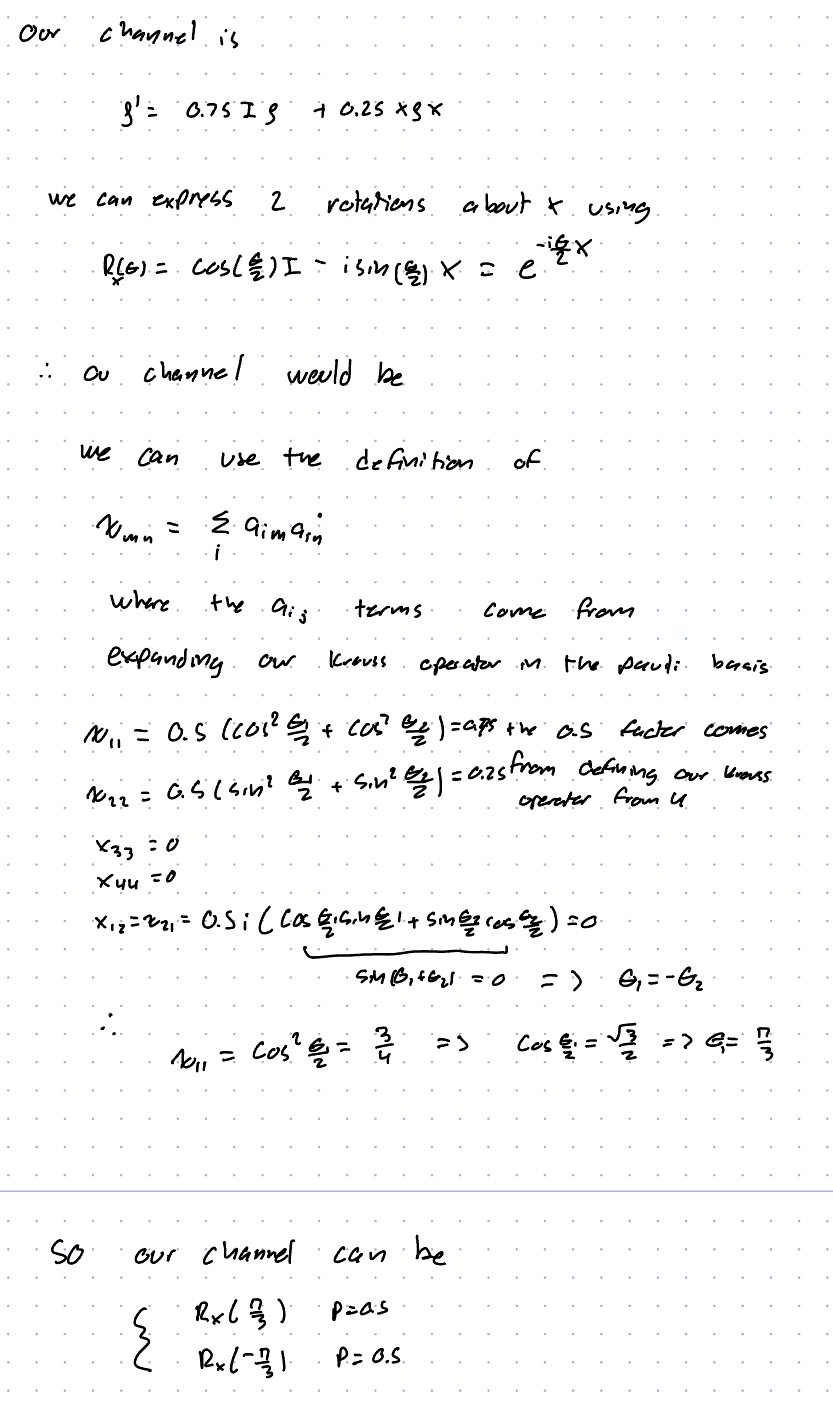